In [44]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor, plot_importance, DMatrix, train
from lightgbm import LGBMRegressor
import shap
from scipy.stats import zscore
from scipy.spatial import cKDTree
import os
import fiona
from geopy.distance import geodesic

In [45]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
caserne = gpd.read_file("../data/caserne/2024_06_21_CIS.shp")
compagnies = gpd.read_file("../data/caserne/2024_06_21_Compagnies.shp")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")

In [46]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def encode_cyclic_feature(df, col, max_val):
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / max_val)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / max_val)
    return df

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

def remove_highly_correlated_features(X, threshold=0.85):
    corr_matrix = X.corr().abs()  # Matrice de corrélation en valeur absolue
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # Partie supérieure

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]  # Colonnes à supprimer
    print(f"🛑 Suppression de {len(to_drop)} features corrélées: {to_drop}")

    return X.drop(columns=to_drop)


doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [47]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

In [48]:
doubs_data = doubs_data.merge(firepoint, on='hex_id', how='left')

threshold = 0.7 * len(doubs_data)
doubs_data.dropna(axis=1, thresh=threshold, inplace=True)

doubs_data.dropna(inplace=True)

In [49]:
caserne['compagnie'] = caserne['compagnie'].replace('Maîche', 'Maiche')

caserne = caserne.to_crs(epsg=4326)
caserne["lon"] = caserne.geometry.x
caserne["lat"] = caserne.geometry.y
compagnies = compagnies.to_crs(epsg=4326)

caserne = caserne.merge(compagnies[['id', 'nom']], left_on='compagnie', right_on='nom', how='left')

caserne = caserne.rename(columns={'id': 'id_compagnie'})

if 'nom' in caserne.columns:
    caserne = caserne.drop(columns=['nom'])

none_count = caserne['id_compagnie'].isna().sum()
print(f"Nombre de casernes sans id_compagnie : {none_count}")

print(caserne[['compagnie', 'id_compagnie']].head())

if 'nom_y' in caserne.columns:
    caserne = caserne.drop(columns=['nom_y'])

KeyError: 'id_compagnie'

In [7]:
doubs_data = gpd.GeoDataFrame(doubs_data, geometry='geometry')
compagnies = gpd.GeoDataFrame(compagnies, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_data = doubs_data.to_crs(epsg=4326)
compagnies = compagnies.to_crs(epsg=4326)

doubs_data['id_compagnie'] = None

for idx, hexagone in doubs_data.iterrows():
    intersecting_companies = compagnies[compagnies.intersects(hexagone['geometry'])]

    if len(intersecting_companies) == 1:
        doubs_data.at[idx, 'id_compagnie'] = intersecting_companies.iloc[0]['id']
    elif len(intersecting_companies) > 1:
        max_area = 0
        best_company_id = None
        for _, company in intersecting_companies.iterrows():
            intersection = hexagone['geometry'].intersection(company['geometry'])
            area = intersection.area
            if area > max_area:
                max_area = area
                best_company_id = company['id']

        doubs_data.at[idx, 'id_compagnie'] = best_company_id

print(doubs_data[['hex_id', 'id_compagnie']].head())

            hex_id id_compagnie
0  871f820aaffffff          4.0
1  871f82d61ffffff         12.0
2  871f82d61ffffff         12.0
3  871f82d4dffffff          1.0
4  871f82700ffffff          5.0


In [8]:
doubs_data.columns

Index(['hex_id', 'raison_sortie', 'date_debut', 'date_fin', 'label', 'year',
       'date', 'departement', 'duree_minutes', 'geometry', 'duree', 'centroid',
       'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday', 'scale0',
       'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway',
       'primary', 'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow', 'sinister', 'id_compagnie'],
      dtype='object')

In [9]:
caserne.head()

,id_pg,sous_type,cs_cod,nom_x,compagnie,geometry,lon,lat,id_compagnie
0,840642,Centre de Secours Principal,25155,BESANCON EST,Besançon,POINT (6.06536 47.26571),6.065359,47.265714,1.0
1,840674,Centre de Secours,25706,PREMIER PLATEAU,Baume-les-Dames,POINT (6.23181 47.24656),6.231807,47.246561,2.0
2,840713,CPI,25703,PLATEAU DE BLAMONT,Montbéliard,POINT (6.84404 47.38538),6.844042,47.385383,6.0
3,840644,Centre de Secours Principal,25462,PONTARLIER,Pontarlier,POINT (6.33503 46.89990),6.335031,46.899903,4.0
4,840712,CPI,25004,ABBEVILLERS,Montbéliard,POINT (6.91975 47.42989),6.919745,47.429894,6.0


In [10]:
compagnies.columns

Index(['id', 'nom', 'num', 'geometry'], dtype='object')

In [11]:
encode_cyclic_feature(doubs_data, 'hour', 24)
encode_cyclic_feature(doubs_data, 'weekday', 7)
encode_cyclic_feature(doubs_data, 'month', 12)

doubs_data['is_summer'] = doubs_data['month'].apply(lambda x: 1 if x in [6, 7, 8] else 0)

In [12]:
casernes_coords = np.radians(caserne[['lat', 'lon']].values)
hex_coords = np.radians(doubs_data[['centroid_lat', 'centroid_lon']].values)

tree = cKDTree(casernes_coords)

distances, indices = tree.query(hex_coords, k=1)
doubs_data['dist_nearest_firestation'] = distances * 6371

hex_set = set(doubs_data['hex_id'])
caserne['hex_id'] = caserne.apply(lambda row: tree.query_ball_point(np.radians([row['lat'], row['lon']]), 0.001), axis=1)
caserne['hex_id'] = caserne['hex_id'].apply(lambda x: x[0] if x else None)
doubs_data['has_firestation'] = doubs_data['hex_id'].apply(lambda x: 1 if x in caserne['hex_id'].values else 0)

doubs_data['firestation_density_10km'] = [len(tree.query_ball_point(p, 10 / 6371)) for p in hex_coords]

elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison


In [13]:
doubs_data.head()

,hex_id,raison_sortie,date_debut,date_fin,label,year,date,departement,duree_minutes,geometry,...,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos,is_summer,dist_nearest_firestation,has_firestation,firestation_density_10km
0,871f820aaffffff,NATURELS,2014-10-02 14:08:53,2014-10-02 19:54:25,1.0,2014.0,2014-10-02,departement-25-doubs,345.533333,"POLYGON ((6.21735 46.89696, 6.21925 46.88490, ...",...,-5.000000e-01,-0.866025,0.433884,-0.900969,-0.866025,0.5,0,0.692017,0,3
1,871f82d61ffffff,NATURELS,2014-10-03 19:33:59,2014-10-03 19:55:31,1.0,2014.0,2014-10-03,departement-25-doubs,21.533333,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",...,-9.659258e-01,0.258819,-0.433884,-0.900969,-0.866025,0.5,0,2.448390,0,3
2,871f82d61ffffff,NATURELS,2014-10-04 19:24:49,2014-10-04 19:59:02,1.0,2014.0,2014-10-04,departement-25-doubs,34.216667,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",...,-9.659258e-01,0.258819,-0.974928,-0.222521,-0.866025,0.5,0,2.448390,0,3
3,871f82d4dffffff,NATURELS,2014-10-04 20:10:43,2014-10-04 20:42:34,1.0,2014.0,2014-10-04,departement-25-doubs,31.850000,"POLYGON ((5.87805 47.22180, 5.88000 47.20981, ...",...,-8.660254e-01,0.500000,-0.974928,-0.222521,-0.866025,0.5,0,6.142163,0,3
4,871f82700ffffff,NATURELS,2014-10-05 12:57:52,2014-10-05 13:24:24,1.0,2014.0,2014-10-05,departement-25-doubs,26.533333,"POLYGON ((6.30249 46.75999, 6.30437 46.74791, ...",...,1.224647e-16,-1.000000,-0.781831,0.623490,-0.866025,0.5,0,2.978427,0,4


Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



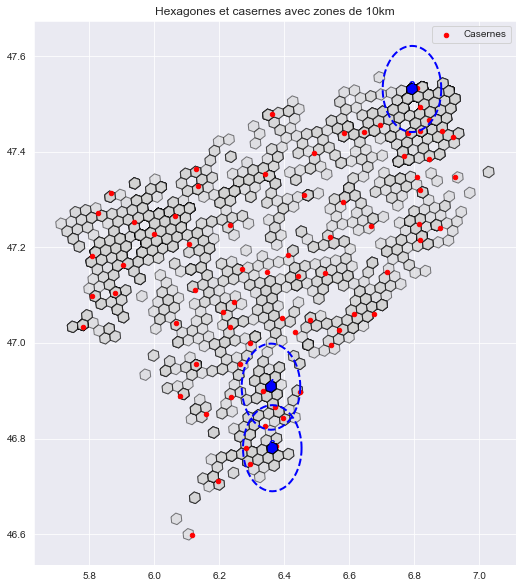

In [14]:
gdf_hex = gpd.GeoDataFrame(doubs_data, geometry='geometry', crs="EPSG:4326")
gdf_caserne = gpd.GeoDataFrame(caserne, geometry=gpd.points_from_xy(caserne.lon, caserne.lat), crs="EPSG:4326")

sample_hex = gdf_hex.sample(3, random_state=42)

circles = sample_hex.geometry.centroid.buffer(10 / 111)

fig, ax = plt.subplots(figsize=(10, 10))
gdf_hex.plot(ax=ax, color="lightgrey", edgecolor="black", alpha=0.5)
gdf_caserne.plot(ax=ax, color="red", markersize=20, label="Casernes")
sample_hex.plot(ax=ax, color="blue", edgecolor="black", label="Hexagones sélectionnés")
gpd.GeoSeries(circles).plot(ax=ax, color="none", edgecolor="blue", linestyle="dashed", linewidth=2, label="Rayon 10km")

for idx, row in sample_hex.iterrows():
    plt.text(row.geometry.centroid.x, row.geometry.centroid.y,
             str(row['firestation_density_10km']), fontsize=12, ha='center', color="blue", weight="bold")

plt.legend()
plt.title("Hexagones et casernes avec zones de 10km")
plt.show()

In [15]:
doubs_data['veg_density'] = doubs_data[['NDVI', 'NDMI', 'NDWI']].mean(axis=1)

road_weights = {
    'motorway': 5,
    'primary': 4,
    'secondary': 3,
    'tertiary': 2,
    'path': 1
}
doubs_data['road_access_index'] = sum(doubs_data[col] * weight for col, weight in road_weights.items())

doubs_data['water_built_ratio'] = doubs_data[['water', 'built']].sum(axis=1)

In [16]:
doubs_data.head()

,hex_id,raison_sortie,date_debut,date_fin,label,year,date,departement,duree_minutes,geometry,...,weekday_cos,month_sin,month_cos,is_summer,dist_nearest_firestation,has_firestation,firestation_density_10km,veg_density,road_access_index,water_built_ratio
0,871f820aaffffff,NATURELS,2014-10-02 14:08:53,2014-10-02 19:54:25,1.0,2014.0,2014-10-02,departement-25-doubs,345.533333,"POLYGON ((6.21735 46.89696, 6.21925 46.88490, ...",...,-0.900969,-0.866025,0.5,0,0.692017,0,3,0.044601,8.441477,3.112007
1,871f82d61ffffff,NATURELS,2014-10-03 19:33:59,2014-10-03 19:55:31,1.0,2014.0,2014-10-03,departement-25-doubs,21.533333,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",...,-0.900969,-0.866025,0.5,0,2.448390,0,3,0.017808,5.081532,6.345595
2,871f82d61ffffff,NATURELS,2014-10-04 19:24:49,2014-10-04 19:59:02,1.0,2014.0,2014-10-04,departement-25-doubs,34.216667,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",...,-0.222521,-0.866025,0.5,0,2.448390,0,3,0.017808,5.081532,6.345595
3,871f82d4dffffff,NATURELS,2014-10-04 20:10:43,2014-10-04 20:42:34,1.0,2014.0,2014-10-04,departement-25-doubs,31.850000,"POLYGON ((5.87805 47.22180, 5.88000 47.20981, ...",...,-0.222521,-0.866025,0.5,0,6.142163,0,3,0.058906,12.957818,10.204597
4,871f82700ffffff,NATURELS,2014-10-05 12:57:52,2014-10-05 13:24:24,1.0,2014.0,2014-10-05,departement-25-doubs,26.533333,"POLYGON ((6.30249 46.75999, 6.30437 46.74791, ...",...,0.623490,-0.866025,0.5,0,2.978427,0,4,0.098529,7.350535,11.164254


In [17]:
hex_coords = np.radians(doubs_data[['centroid_lat', 'centroid_lon']].values)
tree = cKDTree(hex_coords)

def get_neighbors(hex_index, tree, k=6):
    distances, indices = tree.query(hex_coords[hex_index], k=k+1)
    return indices[1:]

def calculate_slope(hex_index, doubs_data, tree):
    neighbors_indices = get_neighbors(hex_index, tree)
    central_elevation = doubs_data['elevation'].iloc[hex_index]
    neighbor_elevations = doubs_data['elevation'].iloc[neighbors_indices].values

    slope = np.mean(np.abs(central_elevation - neighbor_elevations))
    return slope

doubs_data['slope'] = [calculate_slope(i, doubs_data, tree) for i in range(len(doubs_data))]

In [18]:
forest_cols = [
    'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus',
    'Hêtre', 'Mixte', 'Mélèze', 'Peuplier', 'Pin autre', 'Pin maritime',
    'Pin sylvestre', 'Pins mélangés', 'Robinier', 'Sapin, épicéa'
]
doubs_data[forest_cols] = doubs_data[forest_cols].fillna(0)

forest_normalized = doubs_data[forest_cols] / doubs_data[forest_cols].sum(axis=1).replace(0, 1)[:, None]

forest_weights = {
    'Châtaignier': 1, 'Chênes décidus': 1, 'Conifères': 1, 'Douglas': 1,
    'Feuillus': 1, 'Hêtre': 1, 'Mixte': 1, 'Mélèze': 1, 'Peuplier': 1,
    'Pin autre': 1, 'Pin maritime': 1, 'Pin sylvestre': 1, 'Pins mélangés': 1,
    'Robinier': 1, 'Sapin, épicéa': 1
}

doubs_data['forest_index'] = (forest_normalized * list(forest_weights.values())).sum(axis=1)

Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.


In [19]:
doubs_data['urban_index'] = doubs_data['built'] / (doubs_data[['water', 'built']].sum(axis=1))

doubs_data['vegetation_index'] = doubs_data['veg_density'] / doubs_data['veg_density'].max()

doubs_data['terrain_type_index'] = doubs_data['road_access_index'] / doubs_data['road_access_index'].max()

In [20]:
doubs_data.head()

,hex_id,raison_sortie,date_debut,date_fin,label,year,date,departement,duree_minutes,geometry,...,has_firestation,firestation_density_10km,veg_density,road_access_index,water_built_ratio,slope,forest_index,urban_index,vegetation_index,terrain_type_index
0,871f820aaffffff,NATURELS,2014-10-02 14:08:53,2014-10-02 19:54:25,1.0,2014.0,2014-10-02,departement-25-doubs,345.533333,"POLYGON ((6.21735 46.89696, 6.21925 46.88490, ...",...,0,3,0.044601,8.441477,3.112007,82.971522,0.0,1.0,0.309155,0.256877
1,871f82d61ffffff,NATURELS,2014-10-03 19:33:59,2014-10-03 19:55:31,1.0,2014.0,2014-10-03,departement-25-doubs,21.533333,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",...,0,3,0.017808,5.081532,6.345595,7.044182,1.0,1.0,0.123435,0.154633
2,871f82d61ffffff,NATURELS,2014-10-04 19:24:49,2014-10-04 19:59:02,1.0,2014.0,2014-10-04,departement-25-doubs,34.216667,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",...,0,3,0.017808,5.081532,6.345595,7.044182,1.0,1.0,0.123435,0.154633
3,871f82d4dffffff,NATURELS,2014-10-04 20:10:43,2014-10-04 20:42:34,1.0,2014.0,2014-10-04,departement-25-doubs,31.850000,"POLYGON ((5.87805 47.22180, 5.88000 47.20981, ...",...,0,3,0.058906,12.957818,10.204597,0.000000,1.0,1.0,0.408315,0.394310
4,871f82700ffffff,NATURELS,2014-10-05 12:57:52,2014-10-05 13:24:24,1.0,2014.0,2014-10-05,departement-25-doubs,26.533333,"POLYGON ((6.30249 46.75999, 6.30437 46.74791, ...",...,0,4,0.098529,7.350535,11.164254,37.157196,1.0,1.0,0.682966,0.223679


In [21]:
doubs_data.isnull().sum()

hex_id                 0
raison_sortie          0
date_debut             0
date_fin               0
label                  0
                      ..
slope                  0
forest_index           0
urban_index           94
vegetation_index       0
terrain_type_index     0
Length: 81, dtype: int64

In [25]:
XGDoubs = doubs_data.drop(columns=['scale0', 'raison_sortie', 'date_debut', 'date_fin', 'label', 'year', 'date', 'departement', 'geometry', 'centroid', 'month', 'weekday', 'hour', 'duree', 'id_compagnie'])

In [26]:
XGDoubs['urban_index'] = XGDoubs['built'] / (XGDoubs[['water', 'built']].sum(axis=1) + 1e-6)

XGDoubs['urban_index'] = XGDoubs.apply(
    lambda row: row['built'] / (row[['water', 'built']].sum() if row[['water', 'built']].sum() != 0 else 1e-6), axis=1
)

In [37]:
numerical_cols = ['centroid_lon', 'centroid_lat', 'NDVI',
       'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway', 'primary',
       'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow', 'sinister', 'hour_sin', 'hour_cos',
       'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'is_summer',
       'dist_nearest_firestation', 'has_firestation',
       'firestation_density_10km', 'veg_density', 'road_access_index',
       'water_built_ratio', 'slope', 'forest_index', 'urban_index',
       'vegetation_index', 'terrain_type_index']

scaler = StandardScaler()
XGDoubs[numerical_cols] = scaler.fit_transform(XGDoubs[numerical_cols])

In [38]:
XGDoubs.columns

Index(['hex_id', 'duree_minutes', 'centroid_lon', 'centroid_lat', 'NDVI',
       'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway', 'primary',
       'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow', 'sinister', 'hour_sin', 'hour_cos',
       'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'is_summer',
       'dist_nearest_firestation', 'has_firestation',
       'firestation_density_10km', 'veg_density', 'road_access_index',
       'water_built_ratio', 'slope', 'forest_index', 'urban_index',
       'vegetation_index', 'terrain_type_index'],
      dtype='objec

In [40]:
hex_ids = XGDoubs['hex_id'].unique()

train_hex_ids, test_hex_ids = train_test_split(hex_ids, test_size=0.2, random_state=42)

X_train = XGDoubs[XGDoubs['hex_id'].isin(train_hex_ids)].drop(columns=['duree_minutes', 'hex_id'])
y_train = XGDoubs[XGDoubs['hex_id'].isin(train_hex_ids)]['duree_minutes']

X_test = XGDoubs[XGDoubs['hex_id'].isin(test_hex_ids)].drop(columns=['duree_minutes', 'hex_id'])
y_test = XGDoubs[XGDoubs['hex_id'].isin(test_hex_ids)]['duree_minutes']

In [41]:
dtrain = DMatrix(X_train, label=y_train)
dtest = DMatrix(X_test, label=y_test)

params = {
    'objective': 'reg:squarederror',  # Type de problème : régression
    'eval_metric': 'rmse',  # Mesure d'évaluation : RMSE
    'max_depth': 6,  # Profondeur maximale des arbres
    'learning_rate': 0.1,  # Taux d'apprentissage
    'n_estimators': 100  # Nombre d'arbres
}

model = train(params, dtrain, num_boost_round=100)

y_pred = model.predict(dtest)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"📊 Performance du modèle XGBoost :")
print(f"✅ MAE  : {mae:.4f}")
print(f"✅ MSE  : {mse:.4f}")
print(f"✅ RMSE : {rmse:.4f}")
print(f"✅ R²   : {r2:.4f}")

[14:09:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "n_estimators" } are not used.



📊 Performance du modèle XGBoost :
✅ MAE  : 40.4790
✅ MSE  : 3809.1832
✅ RMSE : 61.7186
✅ R²   : -0.1112


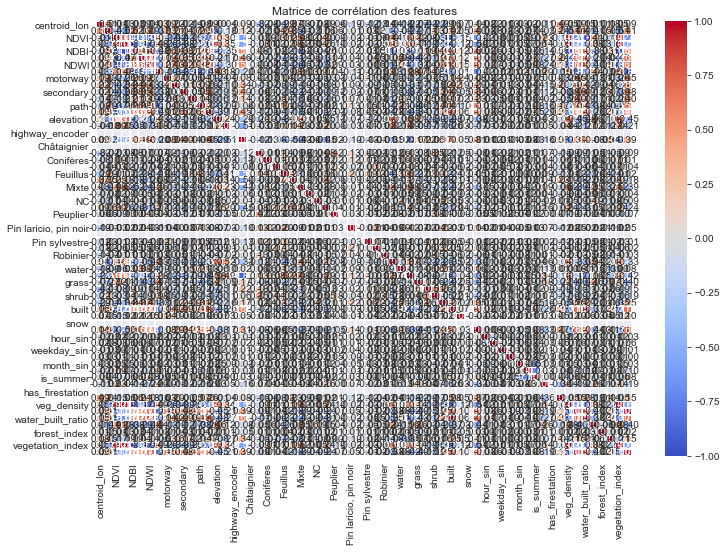

In [42]:
correlation_matrix = XGDoubs[numerical_cols].corr()


plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matrice de corrélation des features')
plt.show()

In [43]:
threshold = 0.9
corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)

strong_corr = corr_pairs[(corr_pairs > threshold) & (corr_pairs < 1)]
strong_corr

NDMI               vegetation_index     0.996132
vegetation_index   NDMI                 0.996132
NDMI               veg_density          0.996132
veg_density        NDMI                 0.996132
water_built_ratio  built                0.995839
built              water_built_ratio    0.995839
NDVI               vegetation_index     0.915471
vegetation_index   NDVI                 0.915471
veg_density        NDVI                 0.915471
NDVI               veg_density          0.915471
NDMI               NDVI                 0.911397
NDVI               NDMI                 0.911397
dtype: float64